# Loading your BWK sample points.
## Loading packages
Let's start with installing the required packages.

In [201]:
try:
    import ee, geemap
except ImportError:
    !pip -q install earthengine-api geemap

import ee, geemap, datetime # ee: Google Earth Engine (GEE) API, geemap: mapping GEE products
import pandas as pd
import matplotlib.pyplot as plt # for figure plotting
import geopandas as gpd # for geospatial dataframes
import os

In [202]:
%pip install "leafmap[maplibre]" # For interactive visualization of maps.
from maplibre.plugins import MapboxDrawControls, MapboxDrawOptions # To select ROI's on your maps.

Connect to your Google Drive to load your dataset within your drive.

In [203]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Load your geospatial dataset.

In [204]:
grasslands = gpd.read_file("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/BWK - graslandfases/selecties/Grassland_classified_final_classes_2022.gpkg")
nograsslands = gpd.read_file("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/BWK - graslandfases/selecties/NoGrassland_classified_final_classes_2022.gpkg")

Create a random subset of nograsslands of +/- 30% of the grasslands dataset.

In [205]:
samplesize = round(len(grasslands) * 30  / 100)
samplesize

1398

In [206]:
nograsslands_samp = nograsslands.sample(n=samplesize, random_state=42)
len(nograsslands_samp)

1398

Combine the datasets

In [207]:
list(grasslands)

['lg_2022',
 'lg_2016',
 'lg_2017',
 'lg_2018',
 'lg_2019',
 'lg_2020',
 'lg_2021',
 'l_7_BWK',
 'lg_2023',
 'Tl_2023',
 'l_8_BWK',
 'FID_BWK',
 'OIDN',
 'UIDN',
 'TAG',
 'EVAL',
 'EENH1',
 'EENH2',
 'EENH3',
 'EENH4',
 'EENH5',
 'EENH6',
 'EENH7',
 'EENH8',
 'V1',
 'V2',
 'V3',
 'HERK',
 'INFO',
 'BWKLABE',
 'HAB1',
 'PHAB1',
 'HAB2',
 'PHAB2',
 'HAB3',
 'PHAB3',
 'HAB4',
 'PHAB4',
 'HAB5',
 'PHAB5',
 'HERKHAB',
 'HERKPHA',
 'HABLEGE',
 'LENGTE',
 'OPPERVL',
 'FID_L20',
 'ORIG_FI',
 'Shp_Lng',
 'Shap_Ar',
 'combi',
 'Level1',
 'Level2',
 'Level3',
 'Level4',
 'Level5',
 'Level4_int_class',
 'geometry']

In [208]:
list(nograsslands_samp)

['OIDN',
 'UIDN',
 'TAG',
 'EVAL',
 'EENH1',
 'EENH2',
 'EENH3',
 'EENH4',
 'EENH5',
 'EENH6',
 'EENH7',
 'EENH8',
 'V1',
 'V2',
 'V3',
 'HERK',
 'INFO',
 'BWKLABEL',
 'HAB1',
 'PHAB1',
 'HAB2',
 'PHAB2',
 'HAB3',
 'PHAB3',
 'HAB4',
 'PHAB4',
 'HAB5',
 'PHAB5',
 'HERKHAB',
 'HERKPHAB',
 'HABLEGENDE',
 'LENGTE',
 'OPPERVL',
 'geometry']

In [209]:
nograsslands_samp = nograsslands_samp.assign(Level4='nograss')

Combine the 2 datasets

In [210]:
nograsslands_samp = nograsslands_samp.to_crs(grasslands.crs)

datagrassbwk2022 = pd.concat([grasslands, nograsslands_samp])
datagrassbwk2022

,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,"MULTIPOLYGON (((29456.773 182071.673, 29446.03...",NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,"MULTIPOLYGON (((29464.828 182021.036, 29464.51...",NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,"MULTIPOLYGON (((29456.111 181990.5, 29456.25 1...",NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,"MULTIPOLYGON (((29479.861 181937.842, 29479.5 ...",NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,"MULTIPOLYGON (((29461.5 181956, 29455.28 18197...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((227089.919 178028.515, 227085....",hc + ms°,223,gh
21645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((165639.228 234689.002, 165578....",n + gml,225,gh
16704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((233461.559 173707.739, 233451....",sf,224,ohab
7003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((141743.666 181877.385, 141740....",qa° + pop,224,hab


Convert multipolygon to points.

In [211]:
datagrassbwk2022["geometry"] = datagrassbwk2022.geometry.centroid
datagrassbwk2022

,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,POINT (29393.716 180241.473),NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,POINT (29464.723 182028.459),NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,POINT (29456.155 182002.022),NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,POINT (29468.71 181967.225),NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,POINT (29457.427 181971.647),NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (227092.6 178072.699),hc + ms°,223,gh
21645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (165643.838 234752.364),n + gml,225,gh
16704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (233451.653 173760.101),sf,224,ohab
7003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (141819.144 182019.059),qa° + pop,224,hab


<Axes: >

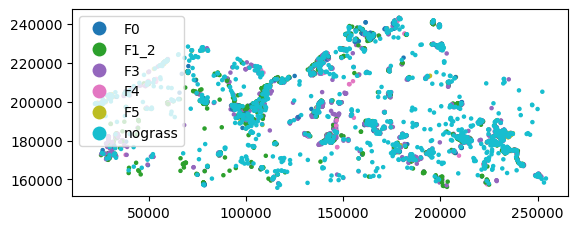

In [212]:
datagrassbwk2022.plot(column="Level4", legend=True, markersize=5)


# Creat full dataset

In [213]:
points_ee = datagrassbwk2022.to_crs("EPSG:4326")
points_ee


,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,POINT (2.6534 50.91996),NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,POINT (2.65382 50.93604),NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,POINT (2.65371 50.9358),NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,POINT (2.6539 50.93549),NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F3_5,F3_5,F3,F3,F3,2.0,POINT (2.65374 50.93552),NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (5.46488 50.90786),hc + ms°,223,gh
21645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (4.59365 51.42223),n + gml,225,gh
16704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (5.5543 50.86822),sf,224,ohab
7003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (4.25234 50.9484),qa° + pop,224,hab


In [214]:
import ee
try:
    ee.Initialize(project="ee-sebastiaanverbesselt")
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

print('Earth Engine version:', ee.__version__)
print('geemap version:', geemap.__version__)



Earth Engine version: 1.7.30
geemap version: 0.38.0


In [215]:
def gdf_to_ee(gdf):
    features = []
    for _, row in gdf.iterrows():
        geom = ee.Geometry.Point([row.geometry.x, row.geometry.y])
        features.append(
            ee.Feature(geom, {
                "id": row.name,
                "class": str(row["Level4"]) # Fixed: extracts the actual row value (e.g., 'F0', 'nograss')
            })
        )
    return ee.FeatureCollection(features)

fc = gdf_to_ee(points_ee)


In [216]:
collection_id = "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL"

In [217]:
# Filter the collection for your year

image_coll = (
    ee.ImageCollection(collection_id)
    .filterDate("2022-01-01", "2023-01-01")
)

# Mosaic the overlapping UTM tiles into a single coherent image
image = image_coll.mosaic()

samples_fc = image.sampleRegions(
    collection=fc,
    scale = 10,
    geometries=True
)

samples_fc

/usr/local/lib/python3.12/dist-packages/IPython/core/formatters.py:345: UserWarning: Getting info failed with: 'Collection query aborted after accumulating over 5000 elements.'. Falling back to string repr.
  return method()


In [218]:
# Use Earth Engine's computeFeatures API to stream pages of vector data
# directly into a native GeoPandas GeoDataFrame
embeddings_gdf = ee.data.computeFeatures({
    'expression': samples_fc,
    'fileFormat': 'GEOPANDAS_GEODATAFRAME'
})

# Explicitly re-assign the WGS 84 Coordinate Reference System
embeddings_gdf.crs = 'EPSG:4326'

In [219]:
embeddings_gdf

,geometry,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,A56,A57,A58,A59,A60,A61,A62,A63,class,id
0,POINT (2.6534 50.91997),-0.206936,-0.214133,-0.153787,0.041584,0.055363,-0.015748,0.186082,0.003014,0.108512,...,-0.130165,-0.022207,-0.055363,-0.041584,0.032541,-0.108512,-0.032541,-0.093564,F3,0
1,POINT (2.65385 50.93605),-0.259900,-0.119093,-0.044844,0.017778,-0.041584,-0.088827,0.103406,0.066990,0.160000,...,-0.113741,-0.041584,-0.015748,-0.079723,0.048228,-0.160000,-0.022207,-0.103406,F3,1
2,POINT (2.65367 50.93578),-0.228897,-0.186082,-0.098424,0.066990,-0.003937,-0.071111,0.103406,0.041584,0.135886,...,-0.130165,-0.044844,-0.035433,0.038447,0.055363,-0.119093,-0.015748,-0.103406,F3,2
3,POINT (2.65394 50.93551),-0.221453,-0.113741,-0.066990,0.015748,-0.019931,-0.066990,0.108512,0.066990,0.103406,...,-0.093564,-0.010396,0.003937,-0.062991,0.035433,-0.160000,-0.024606,-0.093564,F3,3
4,POINT (2.65376 50.93551),-0.236463,-0.147697,-0.062991,0.027128,-0.022207,-0.071111,0.093564,0.066990,0.135886,...,-0.103406,-0.008858,-0.022207,-0.055363,0.059116,-0.153787,-0.019931,-0.093564,F3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6052,POINT (5.46486 50.90784),-0.172795,-0.244152,-0.035433,-0.051734,0.071111,-0.044844,0.093564,-0.044844,0.066990,...,-0.079723,-0.032541,-0.007443,0.062991,0.088827,-0.048228,0.027128,-0.141730,nograss,12535
6053,POINT (4.59367 51.42222),-0.251965,-0.166336,-0.160000,0.108512,-0.079723,-0.284444,0.088827,0.141730,0.141730,...,0.022207,-0.035433,-0.022207,0.000984,0.084214,-0.172795,0.029773,-0.051734,nograss,21645
6054,POINT (5.55433 50.86823),-0.179377,-0.206936,-0.166336,0.093564,-0.027128,-0.267958,0.062991,0.141730,0.041584,...,0.029773,0.010396,-0.084214,-0.027128,0.113741,-0.135886,0.075356,-0.147697,nograss,16704
6055,POINT (4.25231 50.94836),-0.199862,-0.244152,-0.192910,0.103406,-0.041584,-0.214133,0.051734,0.135886,0.048228,...,0.024606,0.019931,-0.084214,-0.022207,0.141730,-0.124567,-0.010396,-0.172795,nograss,7003


In [220]:
embeddings_gdf.to_csv("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/OutputAlphaEarthEmbeddings/AlphaEarth2022.csv") # Now saved in WGS 84